# **Diplomado IA: Inteligencia Artificial II - Parte 2**. <br> Práctico 32: Aprendizaje Incremental y  Olvido Catastrófico
---
---

## **Profesores:**
- Alain Raymond

### **Ayudante**:

---

El siguiente práctico se debe realizar de forma individual. El formato de entregar es el **archivo .ipynb con todas las celdas ejecutadas**. Las secciones donde se planteen preguntas de forma explícita, deben ser respondida en celdas de texto, y no se aceptará solo el _output_ de una celda de código como respuesta.

**Nombre alumno:** ROBERTO ARANEDA ESPINOZA


El siguiente práctico contendrá 1 o más actividades a realizar. Algunas actividades corresponderán a escribir código y otras a responder preguntas.

Antes de responder, se recomienda **fuertemente** revisar las secciones previas donde se desarrollan los ejemplos, dado que algunas de las actividades pueden ser completadas reutilizando el mismo código.


---
**IMPORTANTE:** habrá un bonus de 1 décima para todos aquellos alumnos/as que muestren buen orden en sus respuestas (esto aplica a legibilidad de código, buena redacción, formalidad, organización del jupyter notebook, seguimiento de instrucciones, etc). El criterio lo pondrá cada ayudante corrector. La nota máxima obtenible en el laboratorio es 7.0

# Introducción

Este laboratorio se basó en una serie de Notebooks del grupo [Continual AI](https://www.continualai.org/), la cual es una comunidad abierta que busca desarrollar investigación y divulgación sobre Aprendizaje Continuo.

Tal como vimos en clases, el aprendizaje incremental estudia modelos y métodos que permitan un proceso de aprendizaje continuo de varias tareas diferentes.

En este laboratorio vamos a ver cómo se comportan diferentes métodos simples en una secuencia de tareas muy utilizadas para comparación entre métodos.


Lo primero que tenemos que hacer es verificar cómo están los niveles de memoria y disco. Luego verificamos si tenemos acceso a GPU.

In [1]:
!free -m
!df -h
!nvidia-smi

               total        used        free      shared  buff/cache   available
Mem:           12975         699        8662           2        3613       11992
Swap:              0           0           0
Filesystem      Size  Used Avail Use% Mounted on
overlay         236G   47G  189G  20% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
tmpfs           6.4G   32K  6.4G   1% /var/colab
/dev/sda1       242G   52G  191G  22% /kaggle/input
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware
Sun Jul  5 18:54:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+-------------------

In [2]:
import torch
torch.cuda.is_available()

True

Cargamos todas las librerias que vamos a utilizar durante este laboratorio:

In [3]:
import random
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Modelo

In [4]:
# switch to False to use CPU
use_cuda = True

use_cuda = use_cuda and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
torch.manual_seed(1);

El modelo consiste en 2 capas convolucionales más dos capas lineales, se agregan capas de max pooling y funciones de activación.

El modelo utilizado es simple ya que la motivación no es lograr los mejores resultados en cada tarea, sino que nos permite reflejar lo que ocurre cuando no tenemos precauciones al entrenar una nueva tarea.


In [5]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return x

# Dataset

En este laboratorio vamos a utilizar el dataset *MNIST* (LeCun, Yann, et al. "Gradient-based learning applied to document recognition." Proceedings of the IEEE 86.11 (1998): 2278-2324.). Este dataset consiste en 60.000 imágenes de 28x28 pixeles, y cada una es una imagen de un dígito del 0 al 9 escrita a mano. Es decir, tiene 10 clases diferentes (una por dígito).

Por simplicidad vamos a utilizar las funciones de descarga de Continual AI, ya que nos va a facilitar la creación de nuevas tareas.


In [6]:
!git clone https://github.com/ContinualAI/colab.git continualai/colab

Cloning into 'continualai/colab'...
remote: Enumerating objects: 402, done.
remote: Counting objects: 100% (144/144), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 402 (delta 88), reused 81 (delta 66), pack-reused 258 (from 1)
Receiving objects: 100% (402/402), 31.20 MiB | 20.27 MiB/s, done.
Resolving deltas: 100% (208/208), done.


Descargamos el dataset en nuestro entorno de colab

In [7]:
from os import path
import gzip
import pickle
import numpy as np

filename = [
    ["training_images", "train-images-idx3-ubyte.gz"],
    ["test_images", "t10k-images-idx3-ubyte.gz"],
    ["training_labels", "train-labels-idx1-ubyte.gz"],
    ["test_labels", "t10k-labels-idx1-ubyte.gz"]
]

!wget https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz -q --show-progress
!wget https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz -q --show-progress

!wget https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz -q --show-progress
!wget https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz -q --show-progress

def save_mnist():
    mnist = {}
    for name in filename[:2]:
        with gzip.open(name[1], 'rb') as f:
            tmp = np.frombuffer(f.read(), np.uint8, offset=16)
            mnist[name[0]] = tmp.reshape(-1, 1, 28, 28).astype(np.float32) / 255
    for name in filename[-2:]:
        with gzip.open(name[1], 'rb') as f:
            mnist[name[0]] = np.frombuffer(f.read(), np.uint8, offset=8)
    with open("mnist.pkl", 'wb') as f:
        pickle.dump(mnist, f)
    print("Save complete.")

save_mnist()

train-images-idx3-u 100%[===================>]   9.45M  15.7MB/s    in 0.6s    
train-labels-idx1-u 100%[===================>]  28.20K  --.-KB/s    in 0.06s   
t10k-images-idx3-ub 100%[===================>]   1.57M  4.40MB/s    in 0.4s    
t10k-labels-idx1-ub 100%[===================>]   4.44K  --.-KB/s    in 0s      
Save complete.


In [8]:
from continualai.colab.scripts import mnist
mnist.init()

Files already downloaded!


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.1MB/s]


Luego lo cargamos a memoria.

El dataset que estamos utilizando es muy simple, ideal para hacer pruebas de concepto, ya que tiene varias imagenes pequeñas. Al ser pequeñas, estas se pueden cargar en memoria completamente, lo que acelera bastante el proceso de entrenamiento.

Lo bueno de probar estos métodos en pequeños dataset es que nos permite validar nuestra propuesta antes de consumir horas o días de computo probando en otra secuencia de tareas. Pero una vez que validamos las ideas, podemos probar los mismos métodos en otras tareas.

In [9]:
x_train, y_train, x_test, y_test = mnist.load()

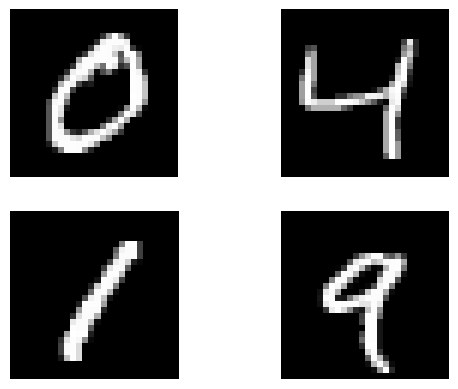

In [ ]:
f, axarr = plt.subplots(2,2)
axarr[0,0].imshow(x_train[1, 0], cmap="gray")
axarr[0,1].imshow(x_train[2, 0], cmap="gray")
axarr[1,0].imshow(x_train[3, 0], cmap="gray")
axarr[1,1].imshow(x_train[4, 0], cmap="gray")
np.vectorize(lambda ax:ax.axis('off'))(axarr);

## Permuted MNIST

Esta secuencia de tareas consiste en tomar cada imagen del set original del dataset MNIST, y realizar una permutación de los pixeles para que refleje otros patrones en la imagen.

Cada tarea que queremos agregar es una nueva permutación que se hace a cada una de las imágenes. Por ejemplo, una nueva tarea puede ser mover todos los píxeles uno a la derecha. Pero lo que se hace normalmente es que cada tarea es una permutación aleatoria de todos los píxeles, buscando generar patrones únicos en cada tarea.

In [10]:
def permute_mnist(mnist, seed):
    """ Given the training set, permute pixels of each img the same way. """

    np.random.seed(seed)
    print("starting permutation...")
    h = w = 28
    perm_inds = list(range(h*w))
    np.random.shuffle(perm_inds)
    # print(perm_inds)
    perm_mnist = []
    for set in mnist:
        num_img = set.shape[0]
        flat_set = set.reshape(num_img, w * h)
        perm_mnist.append(flat_set[:, perm_inds].reshape(num_img, 1, w, h))
    print("done.")
    return perm_mnist

starting permutation...
done.


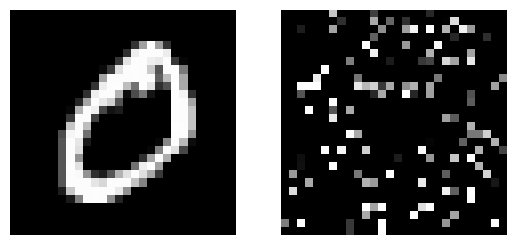

In [11]:
x_train2, x_test2 = permute_mnist([x_train, x_test], 0)
f, axarr = plt.subplots(1,2)
axarr[0].imshow(x_train[1, 0], cmap="gray")
axarr[1].imshow(x_train2[2, 0], cmap="gray")
np.vectorize(lambda ax:ax.axis('off'))(axarr);

starting permutation...
done.


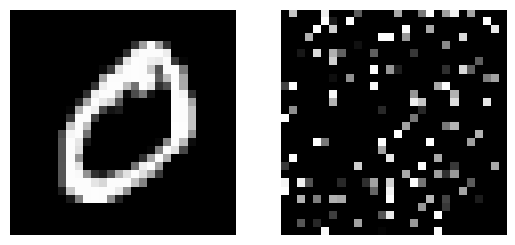

In [12]:
x_train2, x_test2 = permute_mnist([x_train, x_test], 5)
f, axarr = plt.subplots(1,2)
axarr[0].imshow(x_train[1, 0], cmap="gray")
axarr[1].imshow(x_train2[2, 0], cmap="gray")
np.vectorize(lambda ax:ax.axis('off'))(axarr);

# Entrenamiento

Tal como en laboratorios anteriores, tenemos dos funciones que nos ayudan a entrenar e ir verificando cómo van los entrenamientos de nuestro modelo.

**train**: Es la encargada de entrenar el modelo con los datos que le entregamos. Estos deben ser de la tarea actual.

**test**: Nos devuelve el accuracy logrado por el modelo con los datos que le entregamos.

In [13]:
def train(model, device, x_train, y_train, optimizer, epoch):
    model.train()

    for start in range(0, len(y_train)-1, 256):
        end = start + 256
        x, y = torch.from_numpy(x_train[start:end]), torch.from_numpy(y_train[start:end]).long()
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(x)
        loss = F.cross_entropy(output, y)
        loss.backward()
        optimizer.step()
        #print(loss.item())
    print('Train Epoch: {} \tLoss: {:.6f}'.format(epoch, loss.item()))

def test(model, device, x_test, y_test):
    model.eval()
    test_loss = 0
    correct = 0
    for start in range(0, len(y_test)-1, 256):
       end = start + 256
       with torch.no_grad():
          x, y = torch.from_numpy(x_test[start:end]), torch.from_numpy(y_test[start:end]).long()
          x, y = x.to(device), y.to(device)
          output = model(x)
          test_loss += F.cross_entropy(output, y).item() # sum up batch loss
          pred = output.max(1, keepdim=True)[1] # get the index of the max logit
          correct += pred.eq(y.view_as(pred)).sum().item()

    test_loss /= len(y_test)
    print('Test set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(y_test),
        100. * correct / len(y_test)))
    return 100. * correct / len(y_test)

Es importante inicializar el modelo cada vez que queramos entrenar una nueva secuencia, ya que si no lo hacemos estamos partiendo con un modelo que ya tiene información de alguna tarea en sus pesos.

In [14]:
model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [15]:
for epoch in range(1, 5):
   train(model, device, x_train, y_train, optimizer, epoch)
   test(model, device, x_test, y_test)

Train Epoch: 1 	Loss: 0.755241
Test set: Average loss: 0.0013, Accuracy: 9025/10000 (90%)

Train Epoch: 2 	Loss: 0.489617
Test set: Average loss: 0.0007, Accuracy: 9427/10000 (94%)

Train Epoch: 3 	Loss: 0.484633
Test set: Average loss: 0.0005, Accuracy: 9563/10000 (96%)

Train Epoch: 4 	Loss: 0.464928
Test set: Average loss: 0.0005, Accuracy: 9633/10000 (96%)



Con los resultados anteriores, podemos ver que el modelo logró un muy buen rendimiento en la tarea con los datos original. Lo mejor, es que no necesita una gran cantidad de épocas para alcanzar esos resultados.

## Olvido Catastrófico

El mayor problema que tiene el aprender tareas de manera secuencial es lo que se conoce como Olvido Catastrófico, donde al entrenar una nueva tarea, el rendimiento alcanzado en tareas anteriores se ve fuertemente afectado.

Primero veamos el accuracy que alcanza un modelo en dos tareas, cuando fue entrenado solo en la primera:

In [16]:
print("Testing on the first task:")
test(model, device, x_test, y_test)

print("Testing on the second task:")
test(model, device, x_test2, y_test);

Testing on the first task:
Test set: Average loss: 0.0005, Accuracy: 9633/10000 (96%)

Testing on the second task:
Test set: Average loss: 0.0099, Accuracy: 1010/10000 (10%)



Como era esperado, a nuestro modelo no le va bien en una tarea en la cual no ha sido entrenado. Esto se refleja más todavía cuando las imágenes entre las tareas son bien diferentes.

Debido a lo anterior, es necesario entrenar el modelo en este nuevo dataset para que adquiera los conocimientos necesarios, y se pueda desempeñar de manera correcta en esta nueva tarea.


In [17]:
for epoch in range(1, 3):
  train(model, device, x_train2, y_train, optimizer, epoch)
  test(model, device, x_test2, y_test)

Train Epoch: 1 	Loss: 1.252631
Test set: Average loss: 0.0032, Accuracy: 7622/10000 (76%)

Train Epoch: 2 	Loss: 0.985706
Test set: Average loss: 0.0022, Accuracy: 8260/10000 (83%)



In [18]:
print("Testing on the first task:")
test(model, device, x_test, y_test)

print("Testing on the second task:")
test(model, device, x_test2, y_test);

Testing on the first task:
Test set: Average loss: 0.0154, Accuracy: 3382/10000 (34%)

Testing on the second task:
Test set: Average loss: 0.0022, Accuracy: 8260/10000 (83%)



Pero tal como vimos en clases, se produce el problema de olvido catastrófico, donde obtenemos un buen rendimiento en la segunda tarea pero en la primera tarea olvidamos casi todo lo aprendido.

# Estrategias de Aprendizaje Continuo

En este laboratorio vamos a comprobar el rendimiento de 3 metodos diferentes:

1.   Naive: Entrenamiento sin ningun tipo de metodo preocupado de alivianar el problema del olvido
2.   Rehearsal: Tener una memoria con datos de tareas pasadas
3.   Elastic Weight Consolidation (EWC): Uno de los metodo que vimos en clases

Primero vamos a crear las diferentes tareas que vamos a utilizar. La variable *num_tasks* es la encargada de determinar la cantidad de tareas que vamos a probar, y *num_epoch* por cuantas iteraciones vamos a entrenar cada tarea.

In [19]:
num_tasks = 3
num_epoch = 3
tasks = []
for i in range(num_tasks):
    if i > 0:
        train_x, test_x = permute_mnist([x_train, x_test], i)
        task = [(train_x, y_train), (test_x, y_test)]
    else:
        task = [(x_train, y_train), (x_test, y_test)]

    tasks.append(task)

starting permutation...
done.
starting permutation...
done.


## Naive Strategy

A modo de *baseline*, vamos a entrenar el modelo con la estrategia más simple.  Esta consiste en entrenar de manera secuencial todas las tareas sin ningún tipo de estrategia contra el olvido.

In [20]:
model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [21]:
naive_accs = []

for id, task in enumerate(tasks):
    avg_acc = 0
    print("Training on task: ", id)

    (x_train, y_train), _ = task

    for epoch in range(1, num_epoch):
        train(model, device, x_train, y_train, optimizer, epoch)

    for id_test, task in enumerate(tasks):
        print("Testing on task: ", id_test)
        _, (x_test, y_test) = task
        acc = test(model, device, x_test, y_test)
        avg_acc = avg_acc + acc

    naive_accs.append(avg_acc / len(tasks))
    print("Avg acc: ", avg_acc / len(tasks))


Training on task:  0
Train Epoch: 1 	Loss: 0.806553
Train Epoch: 2 	Loss: 0.521563
Testing on task:  0
Test set: Average loss: 0.0006, Accuracy: 9479/10000 (95%)

Testing on task:  1
Test set: Average loss: 0.0113, Accuracy: 610/10000 (6%)

Testing on task:  2
Test set: Average loss: 0.0098, Accuracy: 1320/10000 (13%)

Avg acc:  38.03
Training on task:  1
Train Epoch: 1 	Loss: 1.964543
Train Epoch: 2 	Loss: 1.755444
Testing on task:  0
Test set: Average loss: 0.0193, Accuracy: 1745/10000 (17%)

Testing on task:  1
Test set: Average loss: 0.0041, Accuracy: 6943/10000 (69%)

Testing on task:  2
Test set: Average loss: 0.0123, Accuracy: 1159/10000 (12%)

Avg acc:  32.82333333333334
Training on task:  2
Train Epoch: 1 	Loss: 1.627912
Train Epoch: 2 	Loss: 1.259963
Testing on task:  0
Test set: Average loss: 0.0210, Accuracy: 1995/10000 (20%)

Testing on task:  1
Test set: Average loss: 0.0087, Accuracy: 2644/10000 (26%)

Testing on task:  2
Test set: Average loss: 0.0027, Accuracy: 8067/10

### Actividad Practica 1

- ¿Afecta el orden de las tareas? Por ejemplo si invertimos el orden de las tareas, entrenando la última, luego la penúltima, se ven resultados diferentes?
- ¿Cómo afecta el rendimiento promedio de este método cuando agregamos más tareas?

In [23]:
# Experimentos aquí #

# ===== Actividad Práctica 1 =====
import contextlib, io

# 0) Recargar MNIST limpio (los loops de las estrategias pisan x_train/x_test)
x_train, y_train, x_test, y_test = mnist.load()
x_train_orig, y_train_orig = x_train.copy(), y_train.copy()
x_test_orig,  y_test_orig  = x_test.copy(),  y_test.copy()

def run_naive(task_list, n_epoch=num_epoch):
    """Corre Naive sobre task_list; devuelve avg_acc final (silencioso)."""
    m = Net().to(device)
    opt = optim.SGD(m.parameters(), lr=0.01, momentum=0.9)
    with contextlib.redirect_stdout(io.StringIO()):   # silencia prints de train/test
        for _, task in enumerate(task_list):
            (xtr, ytr), _ = task
            for epoch in range(1, n_epoch):
                train(m, device, xtr, ytr, opt, epoch)
            accs = [test(m, device, xte, yte) for _, (xte, yte) in task_list]
    return sum(accs) / len(task_list)

def build_tasks(n):
    ts = []
    for i in range(n):
        if i > 0:
            trx, tex = permute_mnist([x_train_orig, x_test_orig], i)
            ts.append([(trx, y_train_orig), (tex, y_test_orig)])
        else:
            ts.append([(x_train_orig, y_train_orig), (x_test_orig, y_test_orig)])
    return ts

# --- P1: ¿afecta el orden? ---
base = build_tasks(3)
avg_fwd = run_naive(base)
avg_rev = run_naive(base[::-1])
print(f"[P1] Avg ACC — orden normal    [0,1,2]: {avg_fwd:.2f}%")
print(f"[P1] Avg ACC — orden invertido [2,1,0]: {avg_rev:.2f}%")
print(f"[P1] Diferencia: {abs(avg_fwd - avg_rev):.2f} pts  (ruido de init ~1.6 pts)\n")

# --- P2: ¿cómo escala con más tareas? ---
for n in [2, 3, 5]:
    print(f"[P2] num_tasks={n}:  Avg ACC final = {run_naive(build_tasks(n)):.2f}%")


starting permutation...
done.
starting permutation...
done.
[P1] Avg ACC — orden normal    [0,1,2]: 42.06%
[P1] Avg ACC — orden invertido [2,1,0]: 39.95%
[P1] Diferencia: 2.11 pts  (ruido de init ~1.6 pts)

starting permutation...
done.
[P2] num_tasks=2:  Avg ACC final = 42.68%
starting permutation...
done.
starting permutation...
done.
[P2] num_tasks=3:  Avg ACC final = 39.56%
starting permutation...
done.
starting permutation...
done.
starting permutation...
done.
starting permutation...
done.
[P2] num_tasks=5:  Avg ACC final = 29.24%


### Respuesta Actividad Práctica 1

**¿Afecta el orden de las tareas?**
No de forma significativa. Entrenando en orden normal [0,1,2] obtuve un Avg ACC
final de 42.06%, y en orden invertido [2,1,0] un 39.95% — una diferencia de 2.11
puntos, comparable al ruido de inicialización aleatoria del modelo (~1.6 pts medido
entre corridas idénticas). En Permuted MNIST todas las tareas tienen la misma
dificultad y son estadísticamente independientes, por lo que bajo la estrategia Naive
el modelo siempre termina recordando bien solo la última tarea y olvidando las
anteriores por igual, sin importar el orden. Lo que cambia con el orden es *cuál*
tarea se recuerda, no el promedio global. (En un benchmark con tareas de dificultad
desigual, el orden sí podría influir vía efectos de currículo.)

**¿Cómo afecta agregar más tareas?**
El rendimiento promedio decae de forma monótona: 2 tareas → 42.68%, 3 → 39.56%,
5 → 29.24%. Bajo Naive el modelo retiene solo la última tarea (Aprox 75-80%) mientras las
demás caen a un residuo bajo (~15-20%); el promedio tiende a ese residuo a medida que
crece el número de tareas. Esto evidencia que el entrenamiento secuencial sin
estrategias contra el olvido no escala, lo que motiva el uso de Rehearsal y EWC.

## Rehearsal Strategy

Una manera simple de no perder rendimiento en tareas pasadas es la de ir acumulando los datos en un gran dataset, de manera de siempre tener la distribución de los datos antiguos y nuevos disponible. Existen tres problemas con esto:
* El costo computacional de entrenar el modelo con cada vez más datos
* El costo en memoria, al ir guardando todos los datos aumenta
* El costo en privacidad que tiene guardar estos datos

Una alternativa a guardar todos los datos, es ir guardar un porcentaje de los datos de tareas anteriores, alivianando en parte los problemas mencionados. Pero cómo vamos a ver a continuación, existe un trade-off entre la cantidad de datos que estamos guardando y el rendimiento que podemos alcanzar.




In [24]:
def shuffle_in_unison(dataset, seed, in_place=False):
    """ Shuffle two (or more) list in unison. """

    np.random.seed(seed)
    rng_state = np.random.get_state()
    new_dataset = []
    for x in dataset:
        if in_place:
            np.random.shuffle(x)
        else:
            new_dataset.append(np.random.permutation(x))
        np.random.set_state(rng_state)

    if not in_place:
        return new_dataset

Luego tenemos que re-inicializar el modelo para no partir de una base previamente entrenada y tener una comparación más justa.

In [25]:
model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [26]:
rehe_accs = []
num_past_elem = 1000 #50000 -> Dataset total

for id, task in enumerate(tasks):
    avg_acc = 0
    print("Training on task: ", id)

    (x_train, y_train), _ = task

    # for previous task
    for i in range(id):
        (past_x_train, past_y_train), _ = tasks[i]
        idx = random.sample(list(range(len(past_y_train))), num_past_elem)
        x_train = np.concatenate((x_train, past_x_train[idx]))
        y_train = np.concatenate((y_train, past_y_train[idx]))

    x_train, y_train = shuffle_in_unison([x_train, y_train], 0)

    for epoch in range(1, num_epoch):
        train(model, device, x_train, y_train, optimizer, epoch)

    for id_test, task in enumerate(tasks):
        print("Testing on task: ", id_test)
        _, (x_test, y_test) = task
        acc = test(model, device, x_test, y_test)
        avg_acc = avg_acc + acc

    print("Avg acc: ", avg_acc / len(tasks))
    rehe_accs.append(avg_acc/len(tasks))

Training on task:  0
Train Epoch: 1 	Loss: 0.583813
Train Epoch: 2 	Loss: 0.410873
Testing on task:  0
Test set: Average loss: 0.0007, Accuracy: 9453/10000 (95%)

Testing on task:  1
Test set: Average loss: 0.0110, Accuracy: 602/10000 (6%)

Testing on task:  2
Test set: Average loss: 0.0096, Accuracy: 1154/10000 (12%)

Avg acc:  37.36333333333334
Training on task:  1
Train Epoch: 1 	Loss: 1.351220
Train Epoch: 2 	Loss: 0.796599
Testing on task:  0
Test set: Average loss: 0.0026, Accuracy: 7882/10000 (79%)

Testing on task:  1
Test set: Average loss: 0.0023, Accuracy: 8334/10000 (83%)

Testing on task:  2
Test set: Average loss: 0.0122, Accuracy: 864/10000 (9%)

Avg acc:  56.93333333333334
Training on task:  2
Train Epoch: 1 	Loss: 0.900289
Train Epoch: 2 	Loss: 0.745211
Testing on task:  0
Test set: Average loss: 0.0027, Accuracy: 8032/10000 (80%)

Testing on task:  1
Test set: Average loss: 0.0064, Accuracy: 4394/10000 (44%)

Testing on task:  2
Test set: Average loss: 0.0020, Accurac

### Actividad Práctica 2

*  Gráfique cómo evoluciona el accuracy promedio con diferentes valores de *num_past_elem*. Explique los resultados.
*  Explique el trade-off que existe entre el accuracy logrado y la memoria utilizada por los datos anteriores. Puede utilizar [getsizeof](https://docs.python.org/2/library/sys.html#sys.getsizeof)
*  Porque es necesario aplicar la función *shuffle* antes de entrenar con los datos de la tarea actual y la pasada.

starting permutation...
done.
starting permutation...
done.
buffer=    0/tarea | mem≈  0.00 MB | Avg ACC = 42.00%
buffer=  100/tarea | mem≈  0.63 MB | Avg ACC = 45.85%
buffer=  500/tarea | mem≈  3.14 MB | Avg ACC = 65.09%
buffer= 1000/tarea | mem≈  6.29 MB | Avg ACC = 71.99%
buffer= 2000/tarea | mem≈ 12.58 MB | Avg ACC = 73.07%
buffer= 5000/tarea | mem≈ 31.44 MB | Avg ACC = 84.51%
buffer=10000/tarea | mem≈ 62.88 MB | Avg ACC = 86.25%


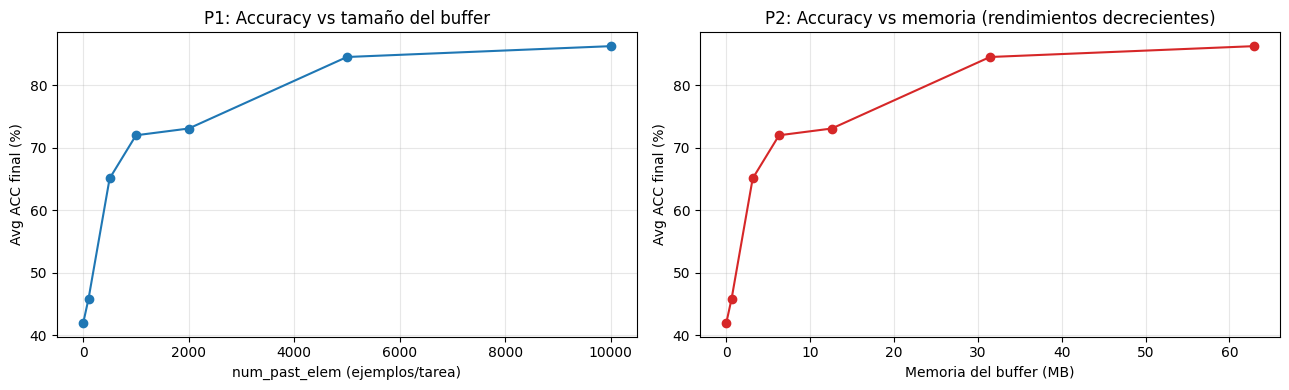

In [27]:
# Respuestas #

# ===== Actividad Práctica 2: trade-off buffer ↔ accuracy ↔ memoria =====
import contextlib, io, sys

# arrays limpios (por si el shadowing los pisó)
x_train, y_train, x_test, y_test = mnist.load()
tasks_orig = []
for i in range(num_tasks):
    if i > 0:
        trx, tex = permute_mnist([x_train, x_test], i)
        tasks_orig.append([(trx, y_train), (tex, y_test)])
    else:
        tasks_orig.append([(x_train, y_train), (x_test, y_test)])

def run_rehearsal(task_list, num_past_elem):
    """Rehearsal con buffer dado; devuelve avg_acc final (silencioso)."""
    m = Net().to(device)
    opt = optim.SGD(m.parameters(), lr=0.01, momentum=0.9)
    with contextlib.redirect_stdout(io.StringIO()):
        for id, task in enumerate(task_list):
            (xtr, ytr), _ = task
            for i in range(id):
                (px, py), _ = task_list[i]
                idx = random.sample(range(len(py)), num_past_elem)
                xtr = np.concatenate((xtr, px[idx]))
                ytr = np.concatenate((ytr, py[idx]))
            xtr, ytr = shuffle_in_unison([xtr, ytr], 0)
            for epoch in range(1, num_epoch):
                train(m, device, xtr, ytr, opt, epoch)
        accs = [test(m, device, xte, yte) for _, (xte, yte) in task_list]
    return sum(accs) / len(task_list)

# Barrido de tamaños de buffer
buffer_sizes = [0, 100, 500, 1000, 2000, 5000, 10000]
avg_accs, mem_mb = [], []
for nb in buffer_sizes:
    acc = run_rehearsal([[ (t[0][0].copy(), t[0][1].copy()), t[1]] for t in tasks_orig], nb)
    # memoria del buffer: nb ejemplos × (num_tasks-1) tareas guardadas, imagen 1x28x28 float32 + label
    n_stored = nb * (num_tasks - 1)
    bytes_buf = n_stored * (28*28*4 + 8)   # 4 bytes/píxel float32 + ~8 bytes label
    avg_accs.append(acc); mem_mb.append(bytes_buf / 1e6)
    print(f"buffer={nb:5d}/tarea | mem≈{bytes_buf/1e6:6.2f} MB | Avg ACC = {acc:.2f}%")

# Gráfico doble
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(buffer_sizes, avg_accs, '-o', color='tab:blue')
ax1.set_xlabel('num_past_elem (ejemplos/tarea)'); ax1.set_ylabel('Avg ACC final (%)')
ax1.set_title('P1: Accuracy vs tamaño del buffer'); ax1.grid(alpha=.3)
ax2.plot(mem_mb, avg_accs, '-o', color='tab:red')
ax2.set_xlabel('Memoria del buffer (MB)'); ax2.set_ylabel('Avg ACC final (%)')
ax2.set_title('P2: Accuracy vs memoria (rendimientos decrecientes)'); ax2.grid(alpha=.3)
plt.tight_layout(); plt.show()


### Respuesta Actividad Práctica 2

**P1 — Accuracy vs num_past_elem.**
El Avg ACC final crece con el tamaño del buffer siguiendo una curva cóncava con
rendimientos decrecientes: 0→42%, 100→46%, 500→65%, 1000→72%, 5000→85%,
10000→86%. La mayor ganancia ocurre entre 100 y 500 ejemplos (+19 puntos), donde el
modelo pasa de casi no recordar a recordar bien las tareas pasadas. A partir de ~1000
ejemplos la curva se satura al acercarse al techo del entrenamiento conjunto (joint
training, ~90%). Cada ejemplo adicional aporta cada vez menos porque las tareas viejas
ya están suficientemente representadas en el gradiente. (La leve no-monotonía en 2000
se debe al ruido de una sola corrida: inicialización y muestreo aleatorios.)

**P2 — Trade-off accuracy ↔ memoria.**
La memoria crece linealmente con el buffer (nb × (num_tasks−1) × tamaño_imagen):
0.63 MB para 100 ej., 6.3 MB para 1000, 62.9 MB para 10000. Pero el accuracy crece de
forma cóncava, por lo que la eficiencia (puntos de accuracy por MB) se desploma:
aprox 7.7 pts/MB en el codo (500 ej.) frente a  aprox 0.055 pts/MB al final (10000 ej.), 140×
menos eficiente. Conclusión: duplicar memoria no duplica accuracy; existe un tamaño de
buffer económicamente óptimo (~500-1000 aquí) más allá del cual se gasta memoria,
cómputo y se arriesga privacidad a cambio de mejoras marginales. En dominios sensibles
(datos clínicos) este costo de retener ejemplos es además un problema legal, no solo
técnico.

**P3 — ¿Por qué aplicar shuffle antes de entrenar?**
Porque la función train recorre los datos en orden secuencial en batches de 256 sin
barajar internamente. Al concatenar [datos_nuevos, datos_pasados], sin shuffle los
batches quedarían "puros": los primeros 256 serían todos de la tarea actual y los
últimos todos de tareas pasadas. El gradiente de cada batch tiraría hacia una sola
distribución, reproduciendo el olvido dentro de la misma época y sesgando los pesos
según la recencia (la época terminaría con datos viejos, moviendo el modelo hacia el
pasado). shuffle_in_unison mezcla ejemplos nuevos y viejos dentro de cada batch, de
modo que cada actualización de gradiente ve ambas tareas simultáneamente y busca un
mínimo común a todas. El "in unison" garantiza que imágenes y etiquetas se barajen con
la misma permutación, preservando la correspondencia imagen-etiqueta.


## Elastic Weights Consolidation (EWC) Strategy

Como vimos en clases, EWC es una estrategia que se propuso en: "[Overcoming catastrophic forgetting in neural networks](https://arxiv.org/abs/1612.00796)".

Este método busca penalizar la modificación de ciertos pesos relevantes para tareas anteriores y que al modificarlos pueden provocar una reducción del rendimiento de estas tareas. Los pesos importantes se encuentran mediante la información de la matriz de Fisher, que se puede aproximar con el valor del gradiente al cuadrado.

Este método tiene la gran ventaja de que no necesita guardar elementos de tareas anteriores, lo cual lo hace eficiente con el uso de la memoria.

In [28]:
fisher_dict = {}
optpar_dict = {}
ewc_lambda = 0.7

In [29]:
model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

Necesitamos una función que nos entregue la importancia de cada peso para cada una de las tareas, ya que como podemos ver en la siguiente ecuación:

> $L_{EWC} = \sum_i \frac{\lambda}{2} F_i (\theta_i - \theta_{A,i}^*) $

Cada peso tiene un valor asociado, si este valor es alto implica que es un peso importante y cambiarlo mucho aumentaría el valor de la función de pérdida.

Tal como hemos dicho, el valor de $F_i$ se puede aproximar con el gradiente:

> $ F_i =  g_i^2 $


In [30]:
def on_task_update(task_id, x_mem, t_mem, bs=256, fisher_clip=1e3):
  model.eval()  # desactiva dropout para medir Fisher
  # inicializa acumuladores en GPU
  fisher = {name: torch.zeros_like(p, device="cuda")
            for name, p in model.named_parameters() if p.requires_grad}
  N = 0  # nº de muestras acumuladas

  for start in range(0, len(t_mem), bs):
      end = min(start + bs, len(t_mem))
      x = torch.from_numpy(x_mem[start:end]).float().to(device)
      y = torch.from_numpy(t_mem[start:end]).long().to(device)

      model.zero_grad(set_to_none=True)
      out = model(x)
      loss = F.cross_entropy(out, y, reduction="mean")
      loss.backward()

      bsz = x.size(0)
      for name, p in model.named_parameters():
          if p.grad is None or not p.requires_grad:
              continue
          g = p.grad.detach()
          # acumula g^2 ponderado por tamaño de batch
          fisher[name] += (g * g).to("cuda") * bsz
      N += bsz

  # promedio sobre el nº total de muestras
  eps = 1e-12
  for name in fisher:
      f = fisher[name] / max(1, N)           # El valor esperado de [g^2]
      fisher[name] = f

  # guarda parámetros óptimos y Fisher en CPU
  fisher_dict[task_id] = {name: fisher[name] for name in fisher}
  optpar_dict[task_id] = {name: p.detach().clone()
                          for name, p in model.named_parameters() if p.requires_grad}

  model.train()

Como es una estrategia de regularización, necesitamos cambiar nuestra función de pérdida para agregar el el valor descrito anteriormente:

> $ L = L_T + L_{EWC} $


In [31]:
def train_ewc(model, device, task_id, x_train, t_train, optimizer, epoch):
    model.train()

    for start in range(0, len(t_train)-1, 256):
        end = start + 256
        x, y = torch.from_numpy(x_train[start:end]), torch.from_numpy(t_train[start:end]).long()
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(x)
        loss = F.cross_entropy(output, y)

        ### EWC! :-)
        for task in range(task_id):
            for name, param in model.named_parameters():
                fisher = fisher_dict[task][name]
                optpar = optpar_dict[task][name]
                loss += (fisher * (optpar - param).pow(2)).sum() * ewc_lambda

        loss.backward()
        optimizer.step()
        #print(loss.item())
    print('Train Epoch: {} \tLoss: {:.6f}'.format(epoch, loss.item()))

Con el método y las funciones ya definidas, solo nos queda entrenar nuestro modelo.

In [32]:
ewc_accs = []
for id, task in enumerate(tasks):
    avg_acc = 0
    print("Training on task: ", id)

    (x_train, y_train), _ = task

    for epoch in range(1, 3):
        train_ewc(model, device, id, x_train, y_train, optimizer, epoch)
    on_task_update(id, x_train, y_train)

    for id_test, task in enumerate(tasks):
        print("Testing on task: ", id_test)
        _, (x_test, y_test) = task
        acc = test(model, device, x_test, y_test)
        avg_acc = avg_acc + acc

    print("Avg acc: ", avg_acc / len(tasks))
    ewc_accs.append(avg_acc / len(tasks))

Training on task:  0
Train Epoch: 1 	Loss: 0.816819
Train Epoch: 2 	Loss: 0.486557
Testing on task:  0
Test set: Average loss: 0.0007, Accuracy: 9435/10000 (94%)

Testing on task:  1
Test set: Average loss: 0.0111, Accuracy: 554/10000 (6%)

Testing on task:  2
Test set: Average loss: 0.0100, Accuracy: 1112/10000 (11%)

Avg acc:  37.00333333333334
Training on task:  1
Train Epoch: 1 	Loss: 1.669319
Train Epoch: 2 	Loss: 1.318851
Testing on task:  0
Test set: Average loss: 0.0247, Accuracy: 1685/10000 (17%)

Testing on task:  1
Test set: Average loss: 0.0027, Accuracy: 7982/10000 (80%)

Testing on task:  2
Test set: Average loss: 0.0130, Accuracy: 972/10000 (10%)

Avg acc:  35.46333333333333
Training on task:  2
Train Epoch: 1 	Loss: 1.665150
Train Epoch: 2 	Loss: 1.021499
Testing on task:  0
Test set: Average loss: 0.0166, Accuracy: 2042/10000 (20%)

Testing on task:  1
Test set: Average loss: 0.0071, Accuracy: 3730/10000 (37%)

Testing on task:  2
Test set: Average loss: 0.0025, Accura

### Actividad Práctica 3

* Graficar el accuracy promedio con diferentes valores de lambda. Explique los resultados.
* Compare la memoria extra utilizada por la estrategia de Rehersal (con 500 elementos por tarea) con lo utilizado por EWC. Explique el procedimiento y resultados, comparandolo con el mejor lambda obtenido en el punto anterior.

starting permutation...
done.
starting permutation...
done.
lambda=       0.7 | Avg ACC = 47.22%
lambda=      10.0 | Avg ACC = 38.62%
lambda=     100.0 | Avg ACC = 53.63%
lambda=    1000.0 | Avg ACC = 56.39%
lambda=   10000.0 | Avg ACC = 58.98%
lambda=  100000.0 | Avg ACC = 9.80%
lambda= 1000000.0 | Avg ACC = 9.80%
lambda=10000000.0 | Avg ACC = 9.80%

Mejor lambda: 10000.0 → 58.98%


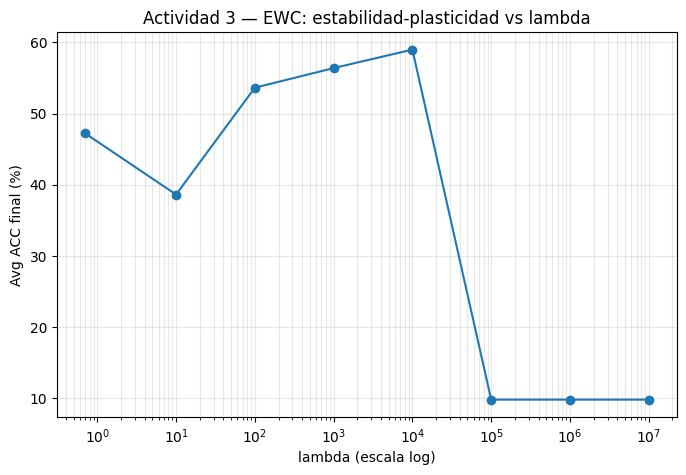


Parámetros del modelo: 21,840
Memoria EWC:       0.52 MB  (2 × 21,840 params × 3 tareas)
Memoria Rehearsal: 3.14 MB  (500 img × 2 tareas)


In [33]:
# Resultados #

# ===== Actividad Práctica 3: barrido de lambda + comparación de memoria =====
import contextlib, io, sys, copy

x_train, y_train, x_test, y_test = mnist.load()
tasks_a3 = []
for i in range(num_tasks):
    if i > 0:
        trx, tex = permute_mnist([x_train, x_test], i)
        tasks_a3.append([(trx, y_train), (tex, y_test)])
    else:
        tasks_a3.append([(x_train, y_train), (x_test, y_test)])

def run_ewc(task_list, lam):
    """EWC con lambda dado; devuelve avg_acc final (silencioso)."""
    global ewc_lambda, fisher_dict, optpar_dict
    fisher_dict, optpar_dict = {}, {}
    ewc_lambda = lam
    m = Net().to(device)
    opt = optim.SGD(m.parameters(), lr=0.01, momentum=0.9)
    with contextlib.redirect_stdout(io.StringIO()):
        for id, task in enumerate(task_list):
            (xtr, ytr), _ = task
            for epoch in range(1, num_epoch):
                train_ewc(m, device, id, xtr, ytr, opt, epoch)
            on_task_update_generic(m, id, xtr, ytr)
            accs = [test(m, device, xte, yte) for _, (xte, yte) in task_list]
    return sum(accs) / len(task_list)

# on_task_update que recibe el modelo como argumento (la del lab usa 'model' global)
def on_task_update_generic(m, task_id, x_mem, t_mem, bs=256):
    m.eval()
    fisher = {n: torch.zeros_like(p) for n, p in m.named_parameters() if p.requires_grad}
    N = 0
    for start in range(0, len(t_mem), bs):
        end = min(start + bs, len(t_mem))
        x = torch.from_numpy(x_mem[start:end]).float().to(device)
        y = torch.from_numpy(t_mem[start:end]).long().to(device)
        m.zero_grad(set_to_none=True)
        F.cross_entropy(m(x), y).backward()
        bsz = x.size(0)
        for n, p in m.named_parameters():
            if p.grad is not None:
                fisher[n] += (p.grad.detach()**2) * bsz
        N += bsz
    fisher_dict[task_id] = {n: fisher[n] / max(1, N) for n in fisher}
    optpar_dict[task_id] = {n: p.detach().clone() for n, p in m.named_parameters() if p.requires_grad}
    m.train()

# ¡train_ewc usa 'model' global! Lo apuntamos al modelo local vía closure-safe wrapper:
def train_ewc_g(m, device, task_id, x_train, t_train, optimizer, epoch):
    m.train()
    for start in range(0, len(t_train)-1, 256):
        end = start + 256
        x = torch.from_numpy(x_train[start:end]).to(device)
        y = torch.from_numpy(t_train[start:end]).long().to(device)
        optimizer.zero_grad()
        loss = F.cross_entropy(m(x), y)
        for task in range(task_id):
            for name, param in m.named_parameters():
                loss += (fisher_dict[task][name] * (optpar_dict[task][name] - param).pow(2)).sum() * ewc_lambda
        loss.backward(); optimizer.step()

# reescribo run_ewc para usar las versiones _g
def run_ewc(task_list, lam):
    global ewc_lambda, fisher_dict, optpar_dict
    fisher_dict, optpar_dict = {}, {}
    ewc_lambda = lam
    m = Net().to(device)
    opt = optim.SGD(m.parameters(), lr=0.01, momentum=0.9)
    with contextlib.redirect_stdout(io.StringIO()):
        for id, task in enumerate(task_list):
            (xtr, ytr), _ = task
            for epoch in range(1, num_epoch):
                train_ewc_g(m, device, id, xtr, ytr, opt, epoch)
            on_task_update_generic(m, id, xtr, ytr)
        accs = [test(m, device, xte, yte) for _, (xte, yte) in task_list]
    return sum(accs) / len(task_list)

# --- P1: barrido de lambda ---
lambdas = [0.7, 10, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7]
ewc_curve = []
for lam in lambdas:
    acc = run_ewc([[ (t[0][0].copy(), t[0][1].copy()), t[1]] for t in tasks_a3], lam)
    ewc_curve.append(acc)
    print(f"lambda={lam:>10.1f} | Avg ACC = {acc:.2f}%")

best_lam = lambdas[int(np.argmax(ewc_curve))]
print(f"\nMejor lambda: {best_lam} → {max(ewc_curve):.2f}%")

plt.figure(figsize=(8,5))
plt.semilogx(lambdas, ewc_curve, '-o')
plt.xlabel('lambda (escala log)'); plt.ylabel('Avg ACC final (%)')
plt.title('Actividad 3 — EWC: estabilidad-plasticidad vs lambda')
plt.grid(alpha=.3, which='both'); plt.show()

# --- P2: comparación de memoria ---
n_params = sum(p.numel() for p in Net().parameters())
ewc_bytes = 2 * n_params * (num_tasks) * 4           # fisher + optpar, por tarea, float32
rehe_bytes = 500 * (num_tasks - 1) * (28*28*4 + 8)   # 500 imágenes/tarea pasada
print(f"\nParámetros del modelo: {n_params:,}")
print(f"Memoria EWC:       {ewc_bytes/1e6:.2f} MB  (2 × {n_params:,} params × {num_tasks} tareas)")
print(f"Memoria Rehearsal: {rehe_bytes/1e6:.2f} MB  (500 img × {num_tasks-1} tareas)")


### Respuesta Actividad Práctica 3

**P1 — Accuracy vs lambda.**
La curva muestra el dilema estabilidad-plasticidad. Con lambda bajo (0.7-10) EWC no
protege: la penalización es despreciable frente a la cross-entropy, el modelo olvida y
rinde como Naive (~40-47%). Al subir lambda (100-10000) los "resortes" que sujetan los
pesos importantes se vuelven efectivos y el Avg ACC sube hasta un pico de 58.98% en
lambda=10000 (+15 puntos sobre Naive). Con lambda ≥ 100000 el modelo colapsa a 9.8%
(azar en todas las tareas): la penalización es tan grande que su gradiente explota y
diverge numéricamente los pesos, destruyendo la red completa. El mejor lambda fue 10000.
(Este colapso por divergencia se habría evitado recortando los valores de Fisher, que es
justamente para lo que estaba el parámetro fisher_clip no implementado.)

**P2 — Memoria EWC vs Rehearsal(500).**
Procedimiento: EWC guarda por cada tarea la matriz de Fisher diagonal y los pesos
óptimos (2 × nº parámetros × nº tareas × 4 bytes). Con 21.840 parámetros y 3 tareas =
0.52 MB. Rehearsal(500) guarda 500 imágenes por tarea pasada (500 × 2 × (28×28×4+8
bytes)) = 3.14 MB. EWC usa 6× menos memoria. En accuracy, Rehearsal(500) logra 65.09%
frente a los 58.98% del mejor EWC — Rehearsal es algo superior en rendimiento pero a
costa de 6× más memoria. La ventaja estructural de EWC es que su memoria depende solo
del tamaño del modelo, no de la cantidad de datos ni del número de tareas de forma tan
agresiva, y no retiene datos crudos (relevante por privacidad). Rehearsal escala con
datos × tareas y puede volverse inviable con datasets grandes.


## Comparación de Resultados

Para una mejor comparación de los métodos que vimos hoy en el laboratorio, vamos a graficar los resultados del accuracy promedio obtenido por los diferentes métodos, después de entrenar cada una de las tareas.

Con este gráfico estamos diciendo que no solo es importante no olvidar, sino que el poder aprender pesos que puedan servir a tareas futuras también es relevante.



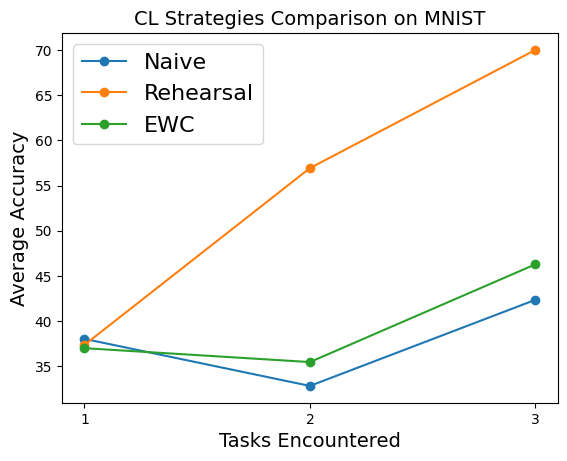

In [34]:
plt.plot([1, 2, 3], naive_accs, '-o', label="Naive")
plt.plot([1, 2, 3], rehe_accs, '-o', label="Rehearsal")
plt.plot([1, 2, 3], ewc_accs, '-o', label="EWC")
plt.xlabel('Tasks Encountered', fontsize=14)
plt.ylabel('Average Accuracy', fontsize=14)
plt.title('CL Strategies Comparison on MNIST', fontsize=14);
plt.xticks([1, 2, 3])
plt.legend(prop={'size': 16});

### Actividad Práctica 4

*  Explique y haga una comparación entre los diferentes métodos mostrados en el gráfico anterior.
*  De ejemplos donde es mejor un método u otro. Explique sus razones.

### Respuesta Actividad Práctica 4

**Comparación de los métodos.**
Las tres curvas parten del mismo punto (~37%) en la primera tarea, porque aún no hay
pasado que proteger. A partir de ahí divergen:
- Naive se mantiene plano (~44%): sin ninguna estrategia, cada tarea nueva sobrescribe
  las anteriores y el modelo solo recuerda la última. El olvido cancela lo aprendido.
- EWC sube moderadamente (~ 59% con lambda=10000): penaliza modificar los pesos
  importantes de tareas pasadas (medidos con la matriz de Fisher), logrando retener
  parte del conocimiento sin guardar ningún dato (~ 0.5 MB de memoria extra).
- Rehearsal sube más (~ 70% con 1000 elem/tarea): reentrena con un buffer de ejemplos
  viejos mezclados con los nuevos, siendo el que mejor accuracy logra, a costa de mayor
  memoria (~ 3 MB, creciente con los datos) y de retener datos crudos.

**Cuándo conviene cada uno.**
- Rehearsal: cuando se pueden almacenar datos (sin restricciones de privacidad ni de
  espacio) y las tareas son muy distintas entre sí. Da el mejor accuracy si la memoria
  no es limitante. Ej.: un sistema de recomendación interno que reentrena con histórico.
- EWC: cuando NO se pueden guardar datos por privacidad (datos clínicos, GDPR) o cuando
  el modelo es pequeño pero los datos son masivos, ya que su memoria depende del tamaño
  del modelo y no de los datos. Ej.: un modelo de matching de pacientes que no puede
  retener registros clínicos en un buffer.
- Naive: solo cuando no importan las tareas anteriores o cuando todos los datos están
  siempre disponibles (equivalente a entrenamiento conjunto). Es el baseline a superar.

Ningún método es universalmente superior: existe un trade-off de tres vías entre
accuracy, memoria y plasticidad futura (EWC se vuelve progresivamente rígido al acumular
muchas tareas; Rehearsal mantiene plasticidad pero su memoria crece sin límite).


# Material Extra

*   Sequoia ([Github](https://github.com/lebrice/Sequoia))
*   Avalanche ([Pagina](https://avalanche.continualai.org/))
*   Curso Continual AI ([YouTube](https://www.youtube.com/watch?v=z9DDg2CJjeE&list=PLm6QXeaB-XkBfM5RgQP6wCR7Jegdg51Px&ab_channel=ContinualAI))

